In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from tqdm.notebook import tqdm

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [4]:
# check if cuda is available
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.empty_cache()
else:
    device = "cpu"

In [5]:
# Load MNIST data
from torchvision import datasets, transforms
mnist_train = datasets.MNIST(root="./datasets", train=True, transform=transforms.ToTensor(), download=True)
mnist_test = datasets.MNIST(root="./datasets", train=False, transform=transforms.ToTensor(), download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.35MB/s]


In [6]:
x_train = mnist_train.data
y_train = mnist_train.targets
x_test = mnist_test.data
y_test = mnist_test.targets

In [7]:
# prepare data
x_train = x_train.type(torch.float32)
x_test = x_test.type(torch.float32)
x_train /= 255
x_test /= 255

In [8]:
x_train = x_train.reshape(-1, 1, 28, 28)
x_test = x_test.reshape(-1, 1, 28, 28)
print(x_train.shape)

torch.Size([60000, 1, 28, 28])


# Training functions

In [9]:
d_train = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
d_test = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))
dl_train = DataLoader(d_train, batch_size=128, shuffle=True)
dl_test = DataLoader(d_test, batch_size=128, shuffle=False)

<ipython-input-9-bbb8175222c7>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d_train = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
<ipython-input-9-bbb8175222c7>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d_test = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))


In [10]:
# training loop
import torch.optim as optim

def fit(net, train=dl_train, valid=dl_test, epochs=10,
        learning_rate=None):
    net = net.to(device)

    if learning_rate is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    loss = torch.nn.BCELoss()
    for e in range(epochs):
        net.train()
        epoch_loss = 0
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, X)
            epoch_loss += l.item()
            l.backward()
            optimizer.step()
        print("Epoch", e, "loss:", epoch_loss / x_train.shape[0])
        #if valid is not None:
        #    print("Accuracy at epoch", e, ":", eval_net(net, valid))

# simple autoencoder

In [11]:
# parameters
d = 10  # encoding dimensionality

In [12]:
m = nn.Sequential(
  # encoder
  nn.Flatten(),
  nn.Linear(28*28, d),
  nn.ReLU(),
  # decoder
  nn.Linear(d, 28*28),
  nn.Sigmoid(),
  nn.Unflatten(1, (1,28,28)),
)

In [13]:
fit(m)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 loss: 0.0025564246855676173


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 loss: 0.0017883825580279032


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 7 loss: 0.0014368923433125019


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8 loss: 0.0014295214146375656


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9 loss: 0.0014240402912100156


In [14]:
def plot_enc_dec(m):
  m.eval()
  fig, axs = plt.subplots(2, 4, sharex=True, sharey=True, squeeze=True)
  for i in range(4):
    axs[0][i].imshow(x_test[i][0,:,:].detach().cpu().numpy())
    pred = m(x_test[i:i+1].to(device))
    axs[1][i].imshow(pred[0,0,:,:].detach().cpu().numpy())

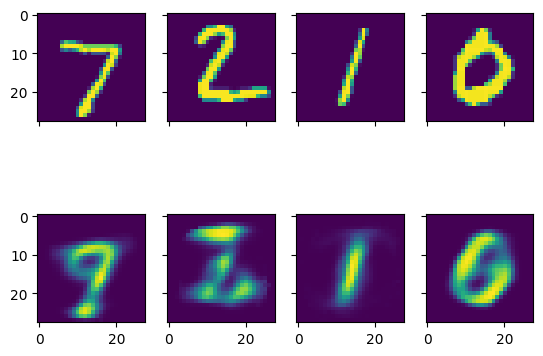

In [15]:
plot_enc_dec(m)

In [ ]:
# test with
#d=10
#d=20
#d=100

# Transposed Convolution

In [16]:
# test image
z = torch.tensor([[1,2], [3,4]], dtype=torch.float32)
print(z)

tensor([[1., 2.],
        [3., 4.]])


In [17]:
z = z.reshape((1,1,2,2))
z

tensor([[[[1., 2.],
          [3., 4.]]]])

In [18]:
l = nn.ConvTranspose2d(1, 1, (1,1))
l.weight

Parameter containing:
tensor([[[[0.2984]]]], requires_grad=True)

In [19]:
with torch.no_grad():
  l.weight=nn.Parameter(torch.tensor([[[[1.0]]]]))
  l.bias=nn.Parameter(torch.zeros(1))
l(z)

tensor([[[[1., 2.],
          [3., 4.]]]], grad_fn=<ConvolutionBackward0>)

In [20]:
l = nn.ConvTranspose2d(1, 1, (1,1), stride=(2,2)) # powiekszamy x 2 razy i y dwa razy
with torch.no_grad():
  l.weight=nn.Parameter(torch.tensor([[[[1.0]]]]))
  l.bias=nn.Parameter(torch.zeros(1))
l(z)

tensor([[[[1., 0., 2.],
          [0., 0., 0.],
          [3., 0., 4.]]]], grad_fn=<ConvolutionBackward0>)

In [21]:
l = nn.ConvTranspose2d(1, 1, (2,2), stride=(2,2))
with torch.no_grad():
  l.weight=nn.Parameter(torch.ones(1,1,2,2))
  l.bias=nn.Parameter(torch.zeros(1))
l(z)

tensor([[[[1., 1., 2., 2.],
          [1., 1., 2., 2.],
          [3., 3., 4., 4.],
          [3., 3., 4., 4.]]]], grad_fn=<ConvolutionBackward0>)

In [22]:
l = nn.ConvTranspose2d(1, 1, (2,2), stride=(1,1))
with torch.no_grad():
  l.weight=nn.Parameter(torch.ones(1,1,2,2))
  l.bias=nn.Parameter(torch.zeros(1))
l(z)

tensor([[[[ 1.,  3.,  2.],
          [ 4., 10.,  6.],
          [ 3.,  7.,  4.]]]], grad_fn=<ConvolutionBackward0>)

# Deep convolutional autoencoder

In [23]:
m = nn.Sequential(
  nn.Conv2d(1, 1, (5,5), stride=(2,2), padding=2),  # encoder
  nn.ReLU(),
  nn.ConvTranspose2d(1, 1, (5,5), stride=(2,2), padding=2, output_padding=1),  # decoder
  # output padding is used to add one extra pixel to keep original size
  nn.Sigmoid(),
)

In [24]:
fit(m)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 loss: 0.004068541824320952


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 loss: 0.0017535700564583142


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 7 loss: 0.0009138008827964465


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8 loss: 0.0008641637279341618


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9 loss: 0.000820144451657931


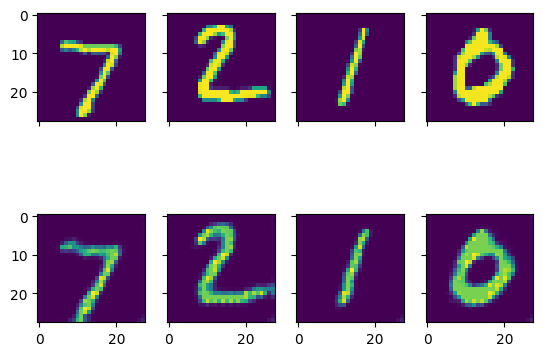

In [25]:
plot_enc_dec(m)

In [26]:
m = nn.Sequential(
  nn.Conv2d(1, 1, (5,5), stride=(2,2), padding=2),  # encoder
  nn.ReLU(),
  nn.Conv2d(1, 1, (5,5), stride=(2,2), padding=2),
  nn.ReLU(),
  nn.ConvTranspose2d(1, 1, (5,5), stride=(2,2), padding=2, output_padding=1),  # decoder
  nn.ReLU(),
  nn.ConvTranspose2d(1, 1, (5,5), stride=(2,2), padding=2, output_padding=1),
  nn.Sigmoid(),
)

In [27]:
fit(m)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 loss: 0.0035760435121754805


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 loss: 0.001570508053402106


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 7 loss: 0.0010724588185548783


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8 loss: 0.0010602861822893222


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9 loss: 0.0010500703585644563


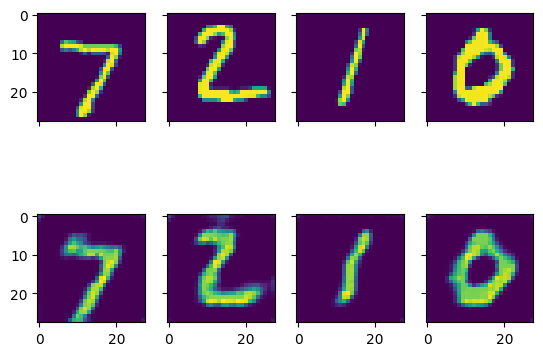

In [28]:
plot_enc_dec(m)

# Denoising autoencoder

In [29]:
class GaussianNoise(nn.Module):
    def __init__(self, stddev):
        super().__init__()
        self.stddev = stddev
    def forward(self, x):
        if self.training:
            return x + torch.randn(x.size(), device=device) * self.stddev
        return x

In [30]:
gn = GaussianNoise(0.01).to(device)
gn(torch.ones(10, device=device))

tensor([1.0165, 1.0087, 1.0129, 0.9985, 1.0170, 1.0029, 1.0040, 0.9876, 0.9826,
        1.0078], device='cuda:0')

In [31]:
d=100

In [32]:
m = nn.Sequential(
  # encoder
  nn.Flatten(),
  GaussianNoise(0.5),
  nn.Linear(28*28, d),
  nn.ReLU(),
  # decoder
  nn.Linear(d, 28*28),
  nn.Sigmoid(),
  nn.Unflatten(1, (1,28,28)),
)

In [33]:
fit(m)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 loss: 0.0015452338740229606


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 loss: 0.00101537175886333


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 7 loss: 0.0008532716435690721


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8 loss: 0.0008502819428841273


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9 loss: 0.000848240427300334


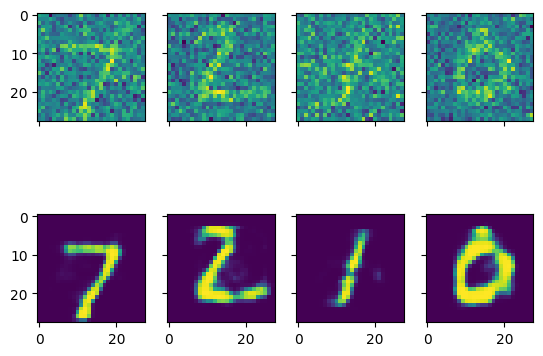

In [34]:
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True, squeeze=True)
m.eval()
for i in range(4):
    inp = x_test[i:i+1]
    inp = inp + torch.randn(size=inp.shape) * 0.5
    axs[0][i].imshow(inp[0,0,:,:].detach().cpu())
    pred = m(inp.to(device))
    axs[1][i].imshow(pred[0,0,:,:].detach().cpu())

# Variational autoencoder

In [35]:
class SampleZ(nn.Module):
    """Sample internal state, compute KL loss."""
    def __init__(self):
        super().__init__()
    def forward(self, mu, log_std):
        eps = torch.randn(size=mu.shape, device=device)
        x = mu + torch.exp(log_std) * eps
        kl = -0.5 * torch.sum(1 + 2 * log_std - mu ** 2 - torch.exp(2 * log_std), axis=-1)
        return x, kl

In [36]:
z = SampleZ()
for i in range(10):
  print(z(torch.zeros(3, device=device),
          torch.zeros(3, device=device)))

(tensor([-0.1665, -0.3920,  0.5633], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([-0.5812,  1.2234,  0.9163], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([ 0.8135,  1.3501, -0.0626], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([-0.5735, -0.1656, -0.4582], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([ 0.3561, -0.4840,  0.0581], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([-0.1540,  1.5740,  2.6320], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([-0.4416, -0.0819,  0.7927], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([ 0.1493,  0.3756, -0.7657], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([-0.0926, -0.8765,  1.4943], device='cuda:0'), tensor(-0., device='cuda:0'))
(tensor([ 0.2033, -1.2136, -0.6510], device='cuda:0'), tensor(-0., device='cuda:0'))


In [37]:
d = 2   # just two hidden vars for easy visualization

In [38]:
decoder = nn.Sequential(
    nn.Linear(d, 28*28),
    nn.Sigmoid(),
    nn.Unflatten(1, (1,28,28)),
)

In [39]:
decoder(torch.zeros(1,2)).shape

torch.Size([1, 1, 28, 28])

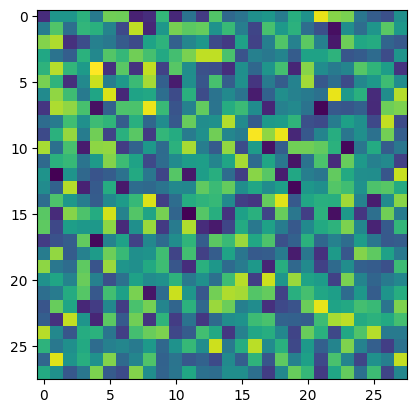

In [40]:
plt.imshow(decoder(torch.tensor([[0.4,0.5]]))[0,0,:,:].cpu().detach())

In [41]:
class VAE(nn.Module):
    def __init__(self, d, beta=1):
        super().__init__()
        self.d = d
        self.beta = beta
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, self.d),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(d, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1,28,28)),
        )
        self.l_mu = nn.Linear(self.d, d)
        self.l_log_std = nn.Linear(self.d, d)
        self.z = SampleZ()
    def encode(self, x):
        e = self.encoder(x)
        mu = self.l_mu(e)
        log_std = self.l_log_std(e)
        z, kl = self.z(mu, log_std)
        return z, kl
    def forward(self, x):
        z, kl = self.encode(x)
        kl = kl / self.beta
        y = self.decoder(z)
        if self.training:
          return y, kl
        else:
          return y

In [42]:
def fit_VAE(net, train=dl_train, valid=dl_test, epochs=10,
        learning_rate=None):
    net = net.to(device)

    if learning_rate is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    loss = torch.nn.BCELoss()
    for e in range(epochs):
        net.train()
        epoch_loss = 0
        epoch_kl_loss = 0
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            pred, kl_loss = net(X)
            kl_loss = kl_loss.mean()
            ce_loss = loss(pred, X)
            l = ce_loss + kl_loss
            epoch_loss += ce_loss.item()
            epoch_kl_loss += kl_loss.item()
            l.backward()
            optimizer.step()
        print("Epoch", e, "ce loss:", epoch_loss / x_train.shape[0], "kl loss:", epoch_kl_loss / x_train.shape[0])

In [43]:
vae = VAE(2, beta=1000)

In [44]:
fit_VAE(vae, epochs=50)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 ce loss: 0.005132282907764117 kl loss: 3.4435518362442963e-06


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 ce loss: 0.003244782495498657 kl loss: 8.147867455651674e-06


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 47 ce loss: 0.002057122597595056 kl loss: 7.762403514546652e-06


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 48 ce loss: 0.0020570821220676104 kl loss: 7.4555335382077225e-06


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 ce loss: 0.0020568427480757235 kl loss: 7.054763477450857e-06


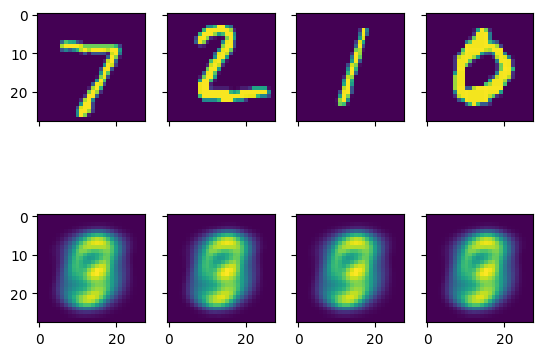

In [45]:
plot_enc_dec(vae)

In [ ]:
# random "7"s

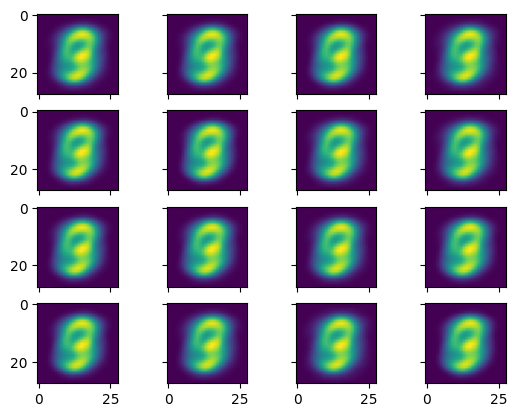

In [46]:
fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, squeeze=True)
for i, ax in enumerate(axs.ravel()):
  ax.imshow(vae(x_test[0:1].to(device)).detach().cpu().numpy()[0,0,:,:])

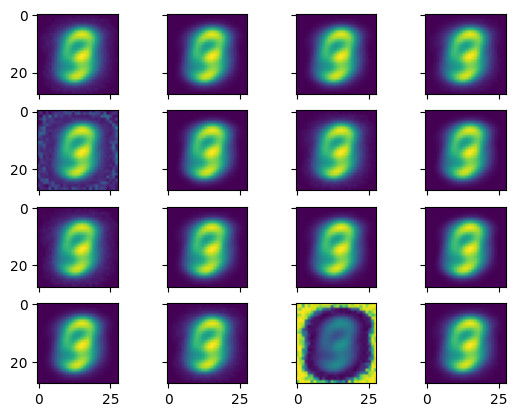

In [47]:
# random digits
fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, squeeze=True)
for i, ax in enumerate(axs.ravel()):
  ax.imshow(vae.decoder(torch.randn(1,2, device=device))[0,0,:,:].detach().cpu())

# Visualize latent space

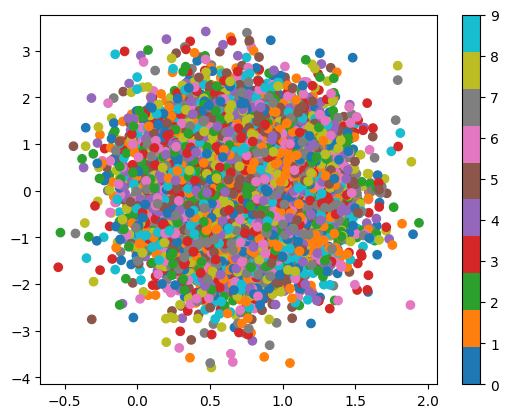

In [48]:
x_test_encoded = vae.encode(x_test.to(device))[0].detach().cpu()
plt.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1], c=y_test, cmap="tab10")
plt.colorbar()
#plt.legend()

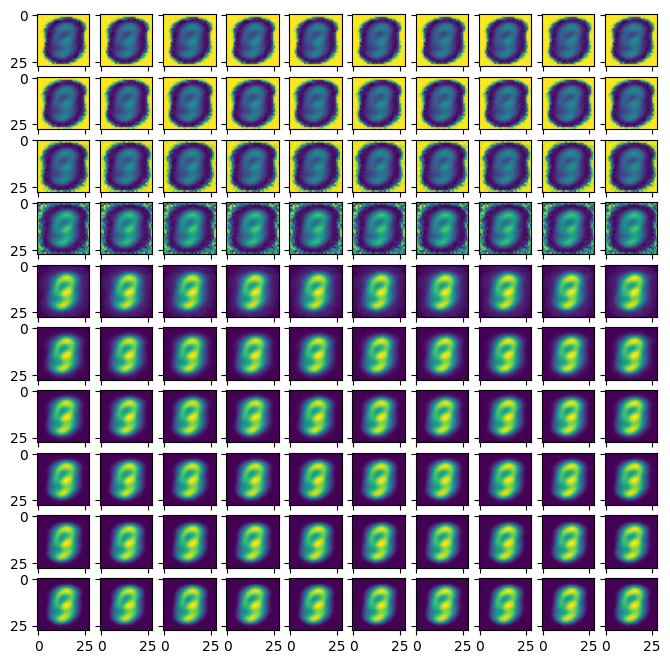

In [49]:
fig, axs = plt.subplots(10, 10, sharex=True, sharey=True, squeeze=True, figsize=(8,8))
for i1, l1 in enumerate(np.linspace(-3, 3, 10)):
  for i2, l2 in enumerate(np.linspace(-3, 3, 10)):
    axs[i1][i2].imshow(vae.decoder(torch.tensor([[l1, l2]], dtype=torch.float32, device=device))[0,0,:,:].detach().cpu())

In [50]:
vae = VAE(2, beta=100)
fit_VAE(vae, epochs=50)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 ce loss: 0.004301632084945837 kl loss: 0.0002101965782387803


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 ce loss: 0.002539209554592768 kl loss: 0.0003595717156305909


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 47 ce loss: 0.0018474976003170014 kl loss: 0.00010211263823633393


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 48 ce loss: 0.0018473424221078555 kl loss: 0.00010258461441844702


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 ce loss: 0.0018475982022782167 kl loss: 0.00010241823340766132


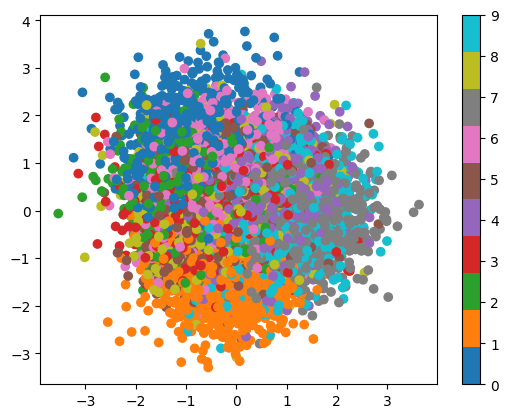

In [51]:
x_test_encoded = vae.encode(x_test.to(device))[0].detach().cpu()
plt.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1], c=y_test, cmap="tab10")
plt.colorbar()
#plt.legend()

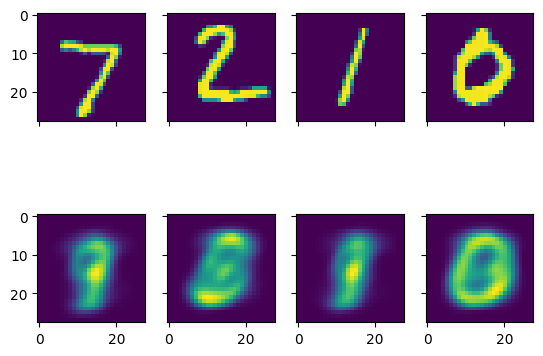

In [52]:
plot_enc_dec(vae)

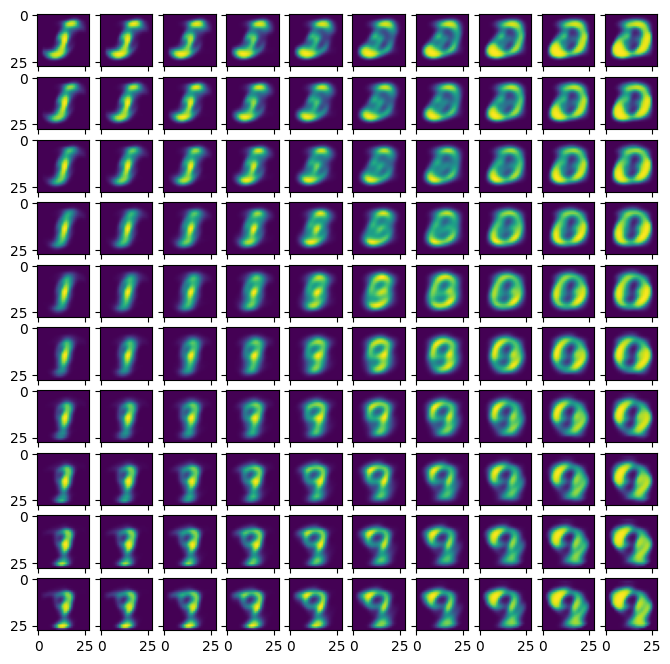

In [53]:
fig, axs = plt.subplots(10, 10, sharex=True, sharey=True, squeeze=True, figsize=(8,8))
for i1, l1 in enumerate(np.linspace(-3, 3, 10)):
  for i2, l2 in enumerate(np.linspace(-3, 3, 10)):
    axs[i1][i2].imshow(vae.decoder(torch.tensor([[l1, l2]], dtype=torch.float32, device=device))[0,0,:,:].detach().cpu())

# Convolutional VAE

In [54]:
# decoder
d=10
cv_decoder = nn.Sequential(
    nn.Linear(d, d*7*7),
    nn.ReLU(),
    nn.Unflatten(1, (d,7,7)),
    nn.ConvTranspose2d(d, d, (5,5), stride=(2,2), padding=2, output_padding=1),
    nn.ReLU(),
    nn.ConvTranspose2d(d, 1, (5,5), stride=(2,2), padding=2, output_padding=1),
    nn.Sigmoid(),
)

In [55]:
cv_decoder(torch.zeros(1,d)).shape

torch.Size([1, 1, 28, 28])

In [56]:
class cv_VAE(nn.Module):
    def __init__(self, d=2, beta=1):
        super().__init__()
        self.d = d
        self.beta = beta
        self.encoder = nn.Sequential(
            nn.Conv2d(1, d, (5,5), stride=(2,2)),
            nn.ReLU(),
            nn.Conv2d(d, 4, (5,5), stride=(2,2)),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.l_mu = nn.LazyLinear(self.d)
        self.l_log_std = nn.LazyLinear(self.d)
        self.z = SampleZ()
        self.decoder = nn.Sequential(
            nn.Linear(d, d*7*7),
            nn.ReLU(),
            nn.Unflatten(1, (d,7,7)),
            nn.ConvTranspose2d(d, d, (5,5), stride=(2,2), padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(d, 1, (5,5), stride=(2,2), padding=2, output_padding=1),
            nn.Sigmoid(),
        )
    def encode(self, x):
        e = self.encoder(x)
        mu = self.l_mu(e)
        log_std = self.l_log_std(e)
        z, kl = self.z(mu, log_std)
        return z, kl
    def forward(self, x):
        z, kl = self.encode(x)
        kl = kl / self.beta
        y = self.decoder(z)
        if self.training:
          return y, kl
        else:
          return y

In [57]:
cvae = cv_VAE(2, beta=100)
fit_VAE(cvae)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 ce loss: 0.0029944723442196846 kl loss: 8.684552627936076e-05


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 ce loss: 0.0020786672634383043 kl loss: 0.00010727708755681912


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 7 ce loss: 0.0018315792933106423 kl loss: 0.0001244956321703891


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8 ce loss: 0.001821358582874139 kl loss: 0.0001284920674438278


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9 ce loss: 0.0018141269855201244 kl loss: 0.00013137642188618581


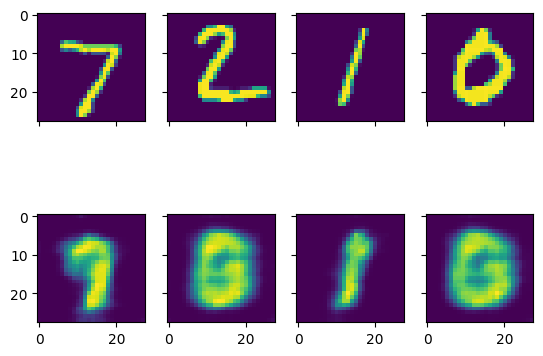

In [58]:
plot_enc_dec(cvae)

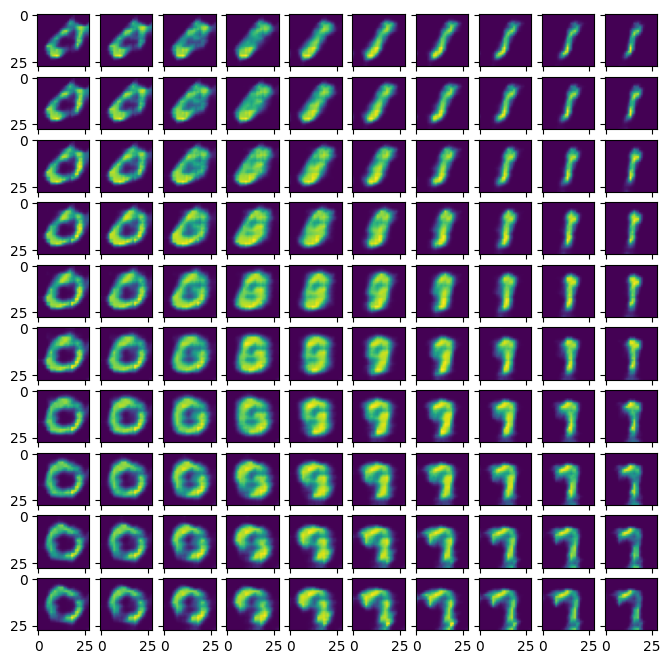

In [59]:
fig, axs = plt.subplots(10, 10, sharex=True, sharey=True, squeeze=True, figsize=(8,8))
for i1, l1 in enumerate(np.linspace(-3, 3, 10)):
  for i2, l2 in enumerate(np.linspace(-3, 3, 10)):
    axs[i1][i2].imshow(cvae.decoder(torch.tensor([[l1, l2]], dtype=torch.float32, device=device))[0,0,:,:].detach().cpu())

In [60]:
cvae2 = cv_VAE(10, beta=100)
fit_VAE(cvae2)

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 0 ce loss: 0.0024509907945990564 kl loss: 0.00010340447806229349


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 ce loss: 0.0018217696723838647 kl loss: 0.0001549702843185514


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 7 ce loss: 0.0014770786615709464 kl loss: 0.00031911238295336566


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8 ce loss: 0.0014666428660353025 kl loss: 0.00032487542362262805


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9 ce loss: 0.001457648306588332 kl loss: 0.00032860281858593227


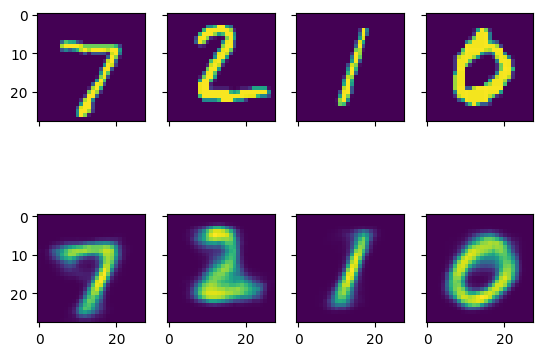

In [61]:
plot_enc_dec(cvae2)

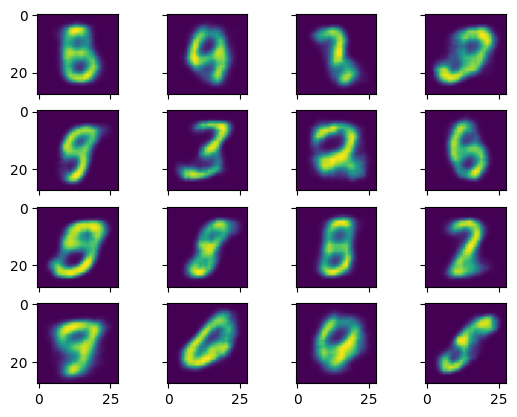

In [62]:
# random digits
cvae2.eval()
fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, squeeze=True)
for i, ax in enumerate(axs.ravel()):
  ax.imshow(cvae2.decoder(torch.randn(1,cvae2.d, device=device))[0,0,:,:].detach().cpu())

# Generative Adversarial Networks

In [63]:
dl_train = DataLoader(d_train, batch_size=1000, shuffle=True) # larger batch size

In [ ]:
# define discriminator and generator subnetworks

In [64]:
# discriminator
D = nn.Sequential(
  nn.Flatten(),
  nn.Linear(28*28, 64),
  nn.ReLU(),
  nn.Linear(64, 1),
)

In [66]:
# generator
dz = 10

G = nn.Sequential(
  nn.Linear(dz, 64),
  nn.ReLU(),
  nn.Linear(64, 28*28),
  nn.Sigmoid(),
  nn.Unflatten(1, (1,28,28)),
)

In [67]:
def fit_GAN(D, G, epochs=10,
            train=dl_train, valid=dl_test,
            learning_rate=None):
    D = D.to(device)
    G = G.to(device)
    if learning_rate is None:
        optimizer_D = optim.Adam(D.parameters())
        optimizer_G = optim.Adam(G.parameters())
    else:
        optimizer_D = optim.Adam(D.parameters(), lr=learning_rate)
        optimizer_G = optim.Adam(G.parameters(), lr=learning_rate)
    loss_D = torch.nn.BCEWithLogitsLoss()
    loss_G = torch.nn.BCEWithLogitsLoss()
    for i in range(epochs): # iterations
        print("Epoch", i)
        for X, _ in tqdm(train):
            ### train the discriminator
            D.train()
            G.eval()
            # real examples
            x_real = X.to(device)
            # artificial examples
            with torch.no_grad(): # don't need gradient here
                z = torch.randn(x_real.shape[0], dz, device=device)
                x_fake = G(z)
                y = torch.ones(2*x_real.shape[0], device=device)
                y[x_real.shape[0]:] = 0
            x = torch.vstack([x_real, x_fake])
            # training iteration
            optimizer_D.zero_grad()
            pred = D(x)
            l = loss_D(pred, y.reshape(-1,1))
            l.backward()
            optimizer_D.step()
            ### train the generator to cheat the discriminator
            D.eval()
            G.train()
            z = torch.randn(x_real.shape[0], dz, device=device)
            y = torch.ones(x_real.shape[0], device=device) # all are fake, but pretend they are true to minimize likelihood
            optimizer_G.zero_grad()
            #D.requires_grad_(False) # don't need gradient here
            pred = D(G(z))
            #D.requires_grad_(True)
            l = loss_G(pred, y.reshape(-1,1))
            l.backward()
            optimizer_G.step()

In [68]:
fit_GAN(D, G, epochs=10)

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

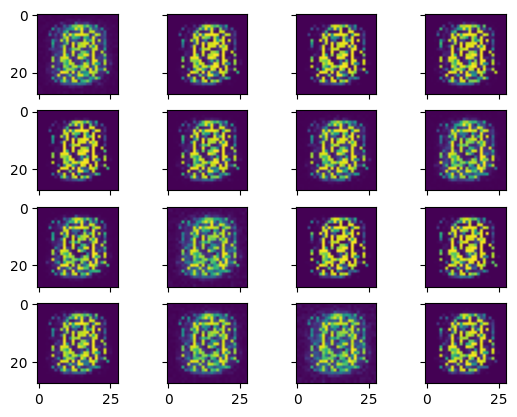

In [69]:
fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, squeeze=True)
for i, ax in enumerate(axs.ravel()):
  ax.imshow(G(torch.randn(1,dz,device=device))[0,0,:,:].detach().cpu())

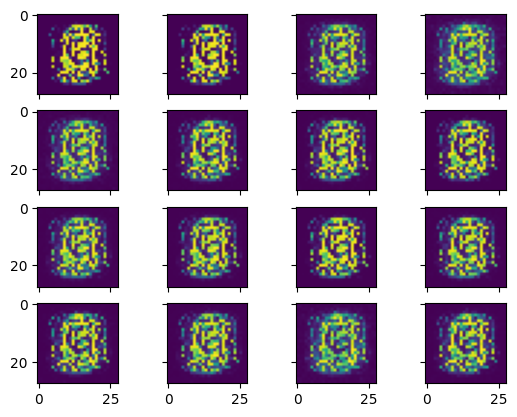

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

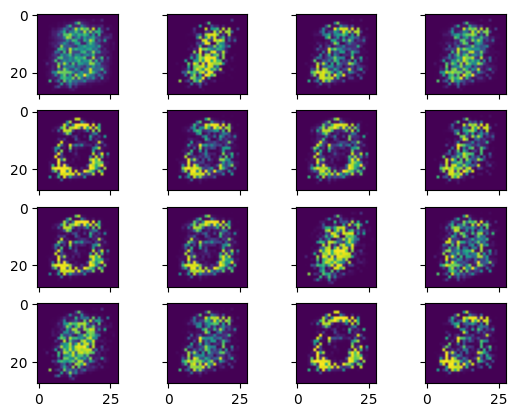

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

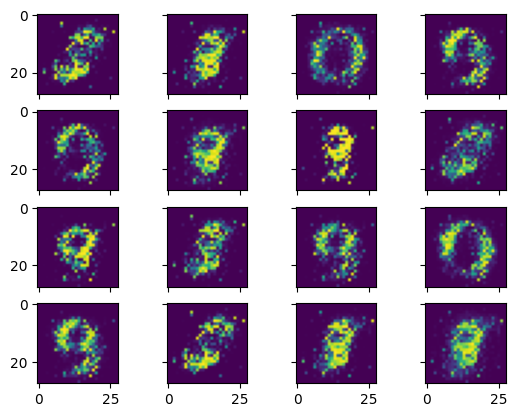

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

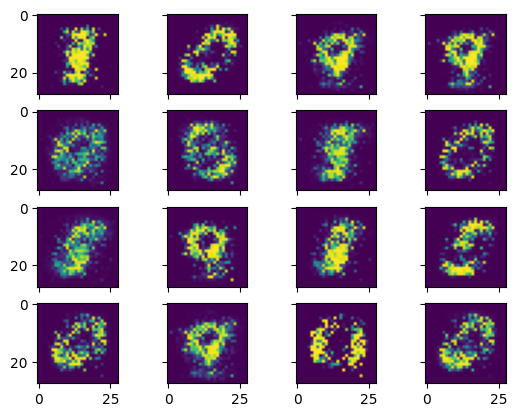

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

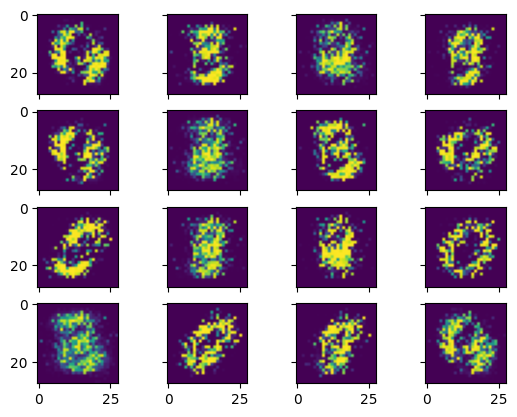

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

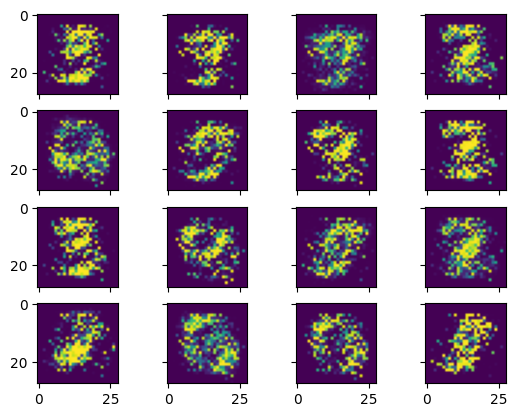

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

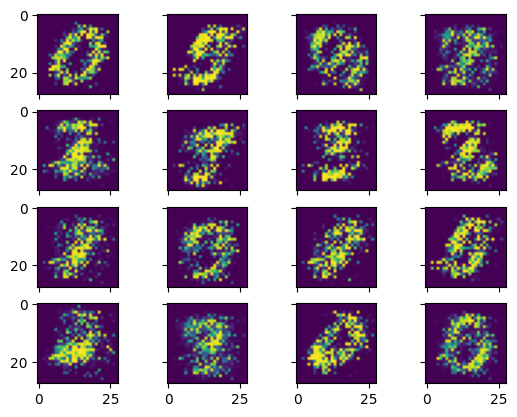

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

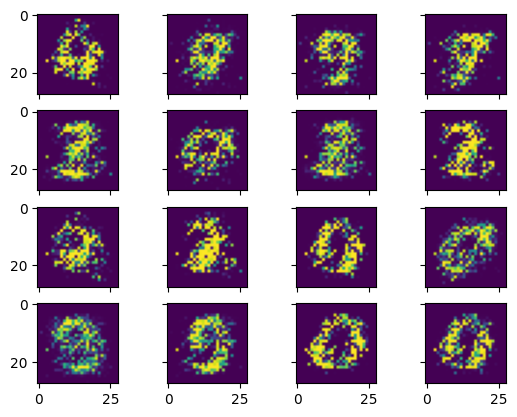

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

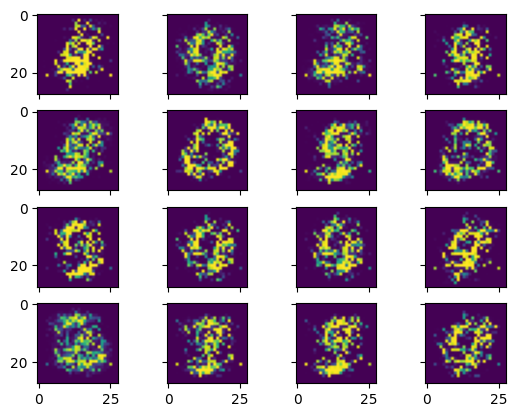

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

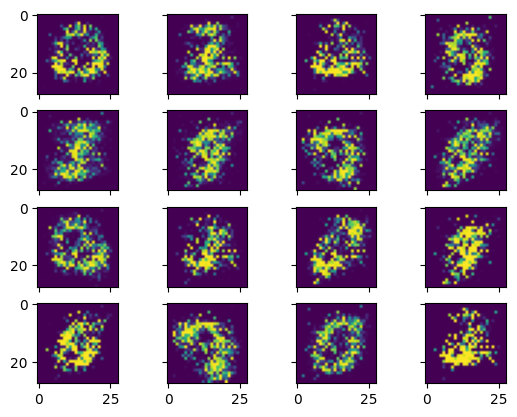

In [70]:
for ii in range(10):
    if ii > 0:
      fit_GAN(D, G, epochs=10)
    fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, squeeze=True)
    for i, ax in enumerate(axs.ravel()):
        G.eval()
        ax.imshow(G(torch.randn(1,dz,device=device))[0,0,:,:].detach().cpu())
    plt.show()

# Convolutional GAN

In [72]:
# discriminator
d=32 # internal dimeansion
Dc = nn.Sequential(
    nn.Conv2d(1, d, (5,5), stride=(2,2), padding=2),
    nn.ReLU(),
    nn.Conv2d(d, d, (5,5), stride=(2,2), padding=2),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(d*7*7, 1),
)

In [73]:
# generator
Gc = nn.Sequential(
    nn.Linear(dz, 7*7),
    nn.ReLU(),
    nn.Unflatten(1, (1,7,7)),
    nn.ConvTranspose2d(1, d, (5,5), stride=(2,2), padding=2, output_padding=1),
    nn.ReLU(),
    nn.ConvTranspose2d(d, 1, (5,5), stride=(2,2), padding=2, output_padding=1),
    nn.Sigmoid(),
)

In [74]:
fit_GAN(Dc, Gc, epochs=10)

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

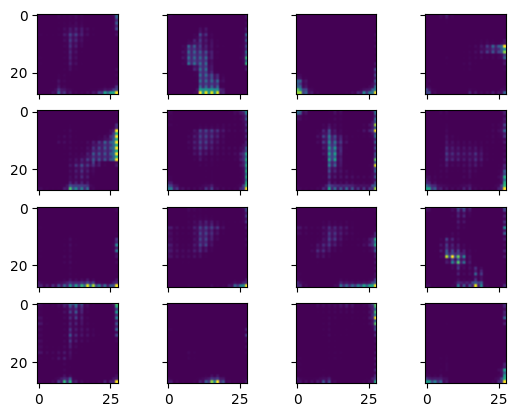

In [75]:
fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, squeeze=True)
for i, ax in enumerate(axs.ravel()):
  ax.imshow(Gc(torch.randn(1,dz,device=device))[0,0,:,:].detach().cpu())

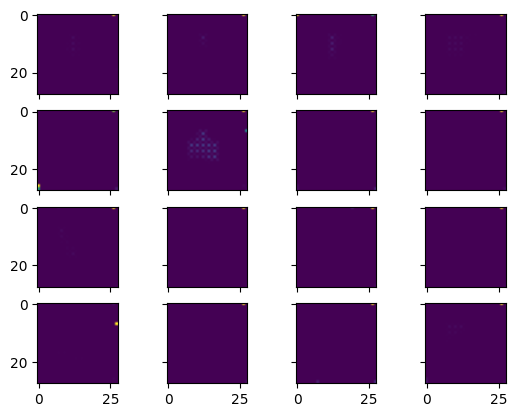

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

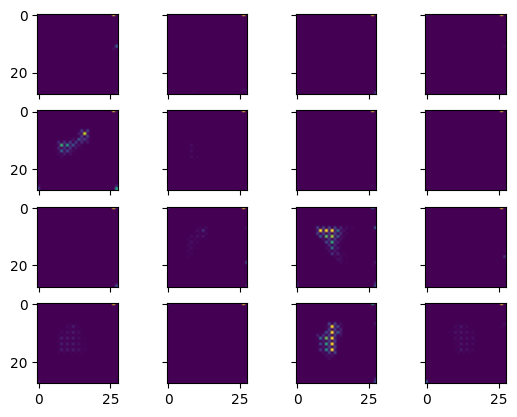

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

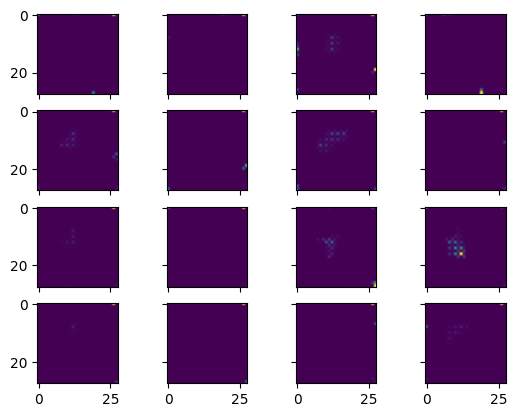

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

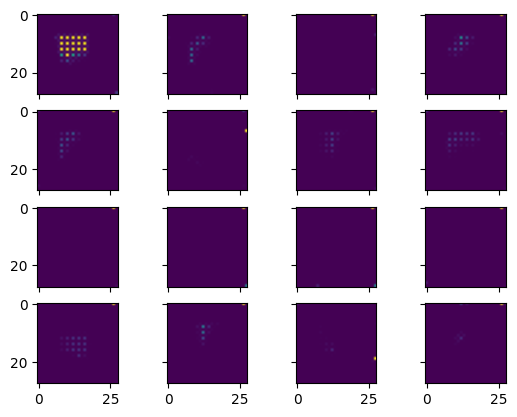

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

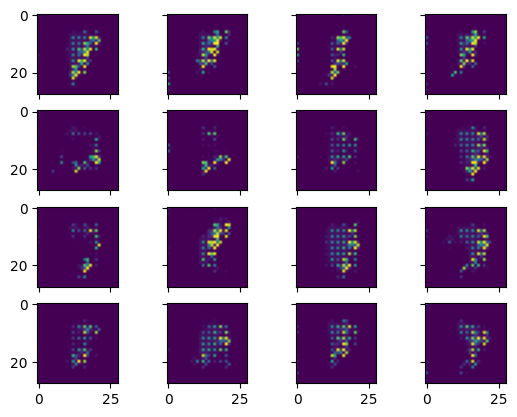

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

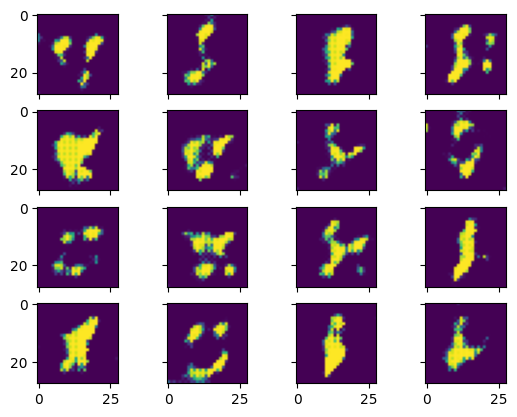

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

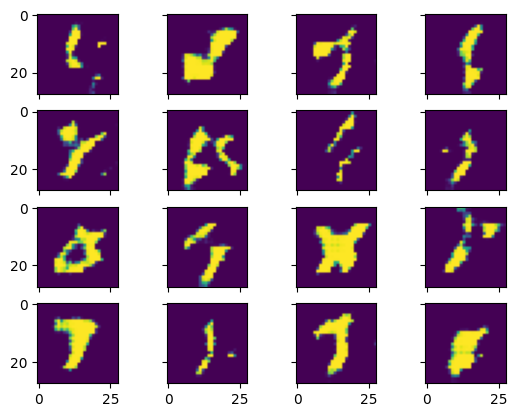

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

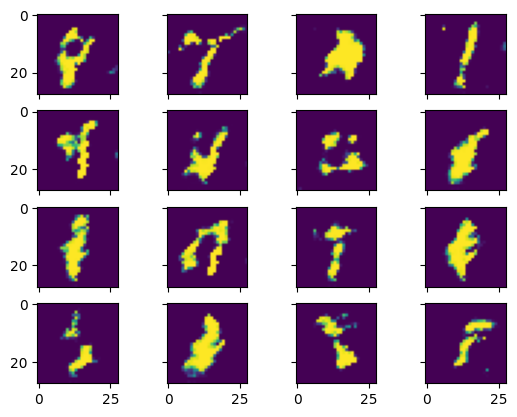

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

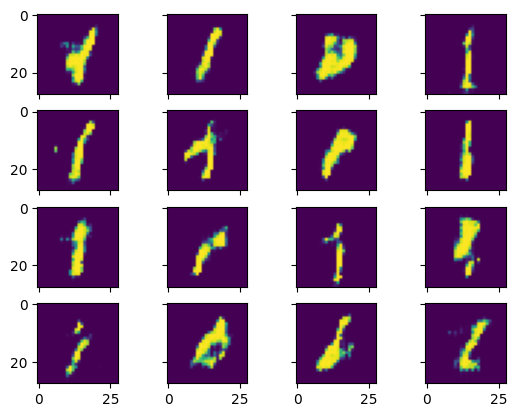

Epoch 0


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 2


...

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 8


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 9


  0%|          | 0/60 [00:00<?, ?it/s]

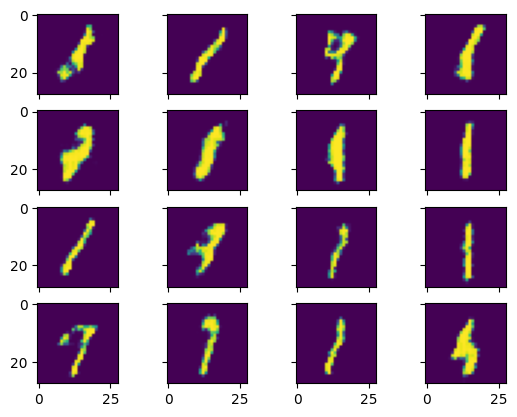

In [77]:
for ii in range(10):
    if ii > 0:
      fit_GAN(Dc, Gc, epochs=10)
    fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, squeeze=True)
    for i, ax in enumerate(axs.ravel()):
        Gc.eval()
        ax.imshow(Gc(torch.randn(1,dz,device=device))[0,0,:,:].detach().cpu())
    plt.show()